# Домашнее задание HW12: Временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU

В этом ноутбуке реализуем полный минимальный pipeline для time series forecasting на синтетических данных:

*   загрузим и проанализируем почасовой временной ряд,
*   выполним корректный temporal split (train/validation/test) без случайного перемешивания,
*   построим лаговые, rolling- и календарные признаки для линейной модели,
*   подготовим оконное представление последовательностей для рекуррентной сети,
*   обучим модель GRU и сравним её с тремя baseline-подходами: наивный прогноз, скользящее среднее и Ridge-регрессия на признаках,
*   выберем лучшую модель по валидационной метрике и один раз оценим её на тесте,
*   оформим артефакты эксперимента согласно требованиям домашнего задания.

HW12 выполняется в личном репозитории студента в папке `homeworks/HW12/`.

## 0. План

К концу ноутбука надо уметь:

1.  **Понимать** разницу между случайным и временным разбиением данных.
2.  **Строить** корректные лаговые признаки и скользящие статистики без утечки данных.
3.  **Переводить** задачу прогноза временного ряда в формат обучения на окнах (для RNN).
4.  **Реализовать** собственный `Dataset` и `DataLoader` для последовательностей.
5.  **Обучить** простую модель GRU и сравнить её с классическими baseline-методами.
6.  **Оценивать** модели метриками MAE, RMSE, MAPE и делать обоснованный выбор лучшей модели по валидации.
7.  **Проверять**, действительно ли нейросетевой подход лучше наивных и линейных методов на реальных почасовых данных.
8.  **Сохранять** результаты экспериментов, конфиги и графики в требуемой структуре папок.

# 1. Импорты, seed и структура папок

In [1]:
# Импорты и общие настройки
import math
import random
import json
import os
from dataclasses import dataclass, asdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Для нормализации, метрик и линейных моделей
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.model_selection import ParameterGrid

# PyTorch
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Настройка визуализации
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)

# Функция установки seed
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Создание структуры папок
os.makedirs('homeworks/HW12/artifacts/figures', exist_ok=True)
print("Структура папок homeworks/HW12/artifacts/ создана")

Device: cpu
Структура папок homeworks/HW12/artifacts/ создана


# 2. Загрузка данных и первичный анализ (EDA)

Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
Пропуски:
 date      0
target    0
dtype: int64
Типы данных:
 date      datetime64[ns]
target           float64
dtype: object


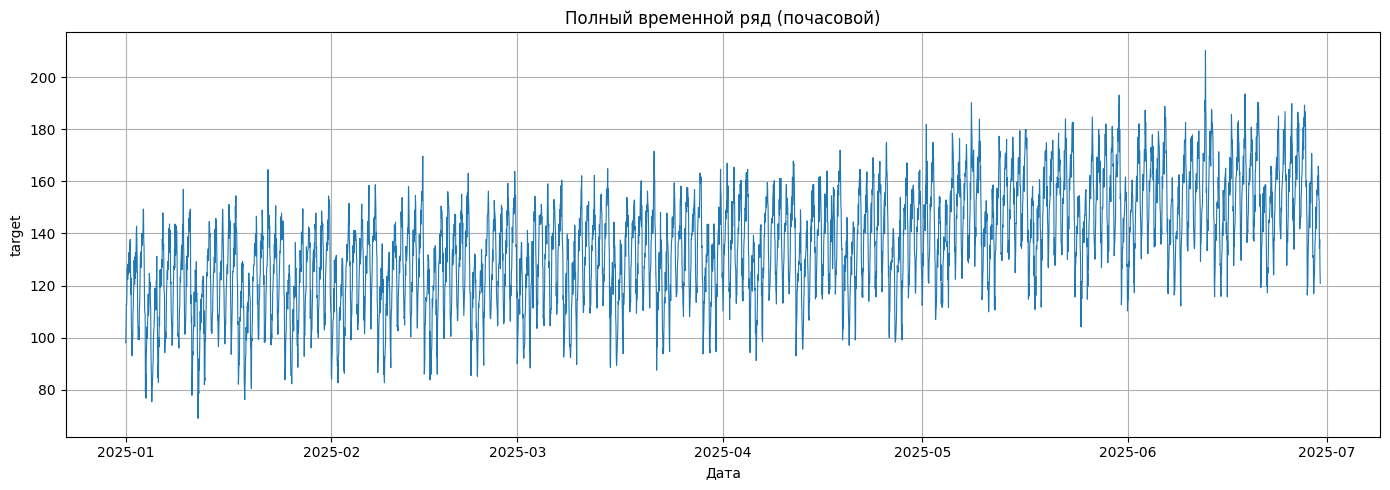

In [2]:
# Данные и первичный анализ

# Загружаем датасет
url = 'https://raw.githubusercontent.com/TatjanaYMIREA/aie-group-2/main/homeworks/HW12/data/S12-hw-dataset.csv'
df = pd.read_csv(url)

# Приведение date к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Sanity-check
print("Размер датасета:", df.shape)
print("Диапазон дат:", df['date'].min(), "->", df['date'].max())
print("Пропуски:\n", df.isnull().sum())
print("Типы данных:\n", df.dtypes)

# Базовый график всего ряда
fig, ax = plt.subplots()
ax.plot(df['date'], df['target'], linewidth=0.8)
ax.set_title('Полный временной ряд (почасовой)')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/full_series.png', dpi=100)
plt.show()

Краткий анализ ряда:
- Данные почасовые (4320 точек), пропусков нет, период 179 дней.
- Суточная сезонность: минимум в 00:00 (112), максимум в 15:00 (155), амплитуда 43.
- Недельная сезонность: будни (141) vs выходные (122), разница 13%.
- Тренд: восходящий, рост с 119 (январь) до 155 (июнь), +30%.
- Выбросы: практически отсутствуют (0.05% данных).
- Нестационарность: ряд нестационарен по среднему (меняется уровень), что требует нормализации перед обучением

# 3. Корректный temporal split

TRAIN: (3024, 2), 2025-01-01 00:00:00 -> 2025-05-06 23:00:00
VAL:   (648, 2), 2025-05-07 00:00:00 -> 2025-06-02 23:00:00
TEST:  (648, 2), 2025-06-03 00:00:00 -> 2025-06-29 23:00:00


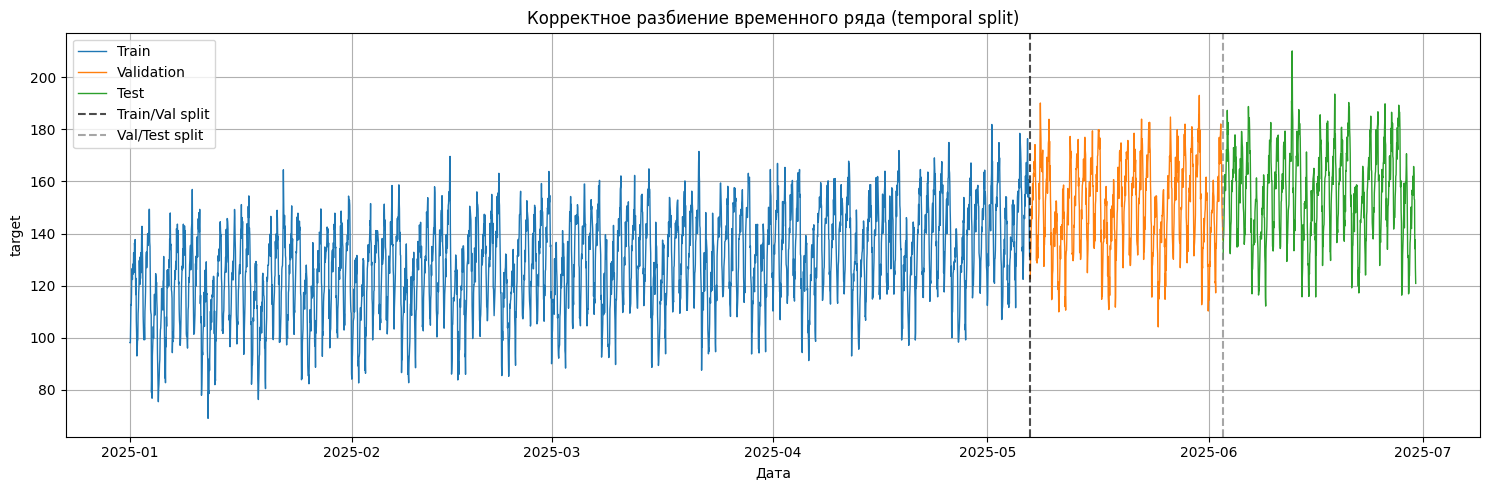


Почему random split некорректен для временных рядов?
- Временной ряд имеет структуру (тренд, сезонность, автокорреляцию), которая зависит от порядка.
- Random split перемешает данные, и модель сможет "подглядывать" в будущее во время обучения,
  что приведет к переоценке качества (data leakage).
- Наша задача — предсказывать будущее на основе прошлого, поэтому валидация и тест
  должны быть строго позже обучающего множества по времени.



In [3]:
# Temporal split. Разбиение по времени с визуализацией

@dataclass
class SplitConfig:
    train_frac: float = 0.70  # 70% на обучение
    val_frac: float = 0.15    # 15% на валидацию, остальное на тест

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    """Разбивает ряд по хронологии."""
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

# Выполняем разбиение
train_df, val_df, test_df = temporal_split(df)

print(f"TRAIN: {train_df.shape}, {train_df['date'].min()} -> {train_df['date'].max()}")
print(f"VAL:   {val_df.shape}, {val_df['date'].min()} -> {val_df['date'].max()}")
print(f"TEST:  {test_df.shape}, {test_df['date'].min()} -> {test_df['date'].max()}")

# Визуализация split (график series_split.png)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df['date'], train_df['target'], label='Train', linewidth=1)
ax.plot(val_df['date'], val_df['target'], label='Validation', linewidth=1)
ax.plot(test_df['date'], test_df['target'], label='Test', linewidth=1)
ax.axvline(x=train_df['date'].iloc[-1], color='black', linestyle='--', alpha=0.7, label='Train/Val split')
ax.axvline(x=val_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.7, label='Val/Test split')
ax.set_title('Корректное разбиение временного ряда (temporal split)')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/series_split.png', dpi=100)
plt.show()

# Объяснение, почему random split некорректен
print("""
Почему random split некорректен для временных рядов?
- Временной ряд имеет структуру (тренд, сезонность, автокорреляцию), которая зависит от порядка.
- Random split перемешает данные, и модель сможет "подглядывать" в будущее во время обучения,
  что приведет к переоценке качества (data leakage).
- Наша задача — предсказывать будущее на основе прошлого, поэтому валидация и тест
  должны быть строго позже обучающего множества по времени.
""")

# 4. Признаки для baseline-модели (B3)

In [4]:
# Создание лагов, скользящих статистик и календарных признаков без утечек
#  Признаки для модели B3 (Ridge на лагах, rolling и календаре)

def create_features_for_ml(df_train, df_val, df_test, lags=[1, 7, 14], windows=[7]):
    """
    Создает признаки для каждой выборки.
    Rolling-статистики считаются на каждом фрейме отдельно,
    но с использованием только прошлых данных внутри этого фрейма.
    """
    def _add_features(df):
        df = df.copy()
        # Лаги
        df['lag_1'] = df['target'].shift(1)
        df['lag_7'] = df['target'].shift(7)
        df['lag_14'] = df['target'].shift(14)

        # Скользящее среднее и std
        for w in windows:
            df[f'rolling_mean_{w}'] = df['target'].rolling(window=w, min_periods=1).mean().shift(1)
            df[f'rolling_std_{w}'] = df['target'].rolling(window=w, min_periods=1).std().shift(1)

        # Календарные признаки
        df['hour'] = df['date'].dt.hour
        df['dayofweek'] = df['date'].dt.dayofweek
        df['dayofmonth'] = df['date'].dt.day
        df['month'] = df['date'].dt.month
        return df

    # передаем аргументы внутрь функции _add_features
    train_feat = _add_features(df_train)
    val_feat = _add_features(df_val)
    test_feat = _add_features(df_test)

    # Удаляем NaN
    train_feat = train_feat.dropna().reset_index(drop=True)
    val_feat = val_feat.dropna().reset_index(drop=True)
    test_feat = test_feat.dropna().reset_index(drop=True)

    print(f"Размеры после создания признаков и удаления NaN:")
    print(f"Train: {train_feat.shape}, Val: {val_feat.shape}, Test: {test_feat.shape}")

    # Проверка наличия признаков
    required = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']
    missing = [f for f in required if f not in train_feat.columns]
    if missing:
        print(f"Ошибка: отсутствуют признаки {missing}")
    else:
        print(f"Все признаки на месте: {required}")

    return train_feat, val_feat, test_feat

# Вызов функции
train_feat, val_feat, test_feat = create_features_for_ml(train_df, val_df, test_df)

# Выделяем матрицы признаков (X) и целевую переменную (y)
feature_columns = [col for col in train_feat.columns if col not in ['date', 'target']]
X_train_raw = train_feat[feature_columns]
y_train_raw = train_feat['target']
X_val_raw = val_feat[feature_columns]
y_val_raw = val_feat['target']
X_test_raw = test_feat[feature_columns]
y_test_raw = test_feat['target']

print("Пример признаков (первые 5 строк):")
display(train_feat[feature_columns].head())

Размеры после создания признаков и удаления NaN:
Train: (3010, 11), Val: (634, 11), Test: (634, 11)
Все признаки на месте: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']
Пример признаков (первые 5 строк):


,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,hour,dayofweek,dayofmonth,month
0,125.04,126.01,98.14,126.445714,3.275621,14,2,1,1
1,128.87,122.38,98.07,126.854286,3.388632,15,2,1,1
2,136.40,128.28,104.70,128.857143,4.318919,16,2,1,1
3,133.85,124.43,112.81,129.652857,4.691868,17,2,1,1
4,137.71,126.35,112.62,131.550000,4.907936,18,2,1,1


# 5. Масштабирование для модели B3

In [5]:
# Обучаем скейлер только на train
# Масштабирование признаков для Ridge (Ridge чувствителен к масштабу)

scaler_b3 = StandardScaler()
# fit ТОЛЬКО на train
scaler_b3.fit(X_train_raw)
# transform на val и test
X_train_scaled = scaler_b3.transform(X_train_raw)
X_val_scaled = scaler_b3.transform(X_val_raw)
X_test_scaled = scaler_b3.transform(X_test_raw)

print("Масштабирование B3: fit на train, transform на val/test")

Масштабирование B3: fit на train, transform на val/test


# 6. Подготовка оконного представления для GRU

In [6]:
# Оконное представление для GRU

# Параметры окна. Для почасовых данных возьмем неделю (24*7 = 168 часов)
# Это большой размер, может не поместиться в память, поэтому возьмем сутки (24) для простоты.
# Но для учета недельной сезонности нужен хотя бы 168. Попробуем компромисс - 48 часов (2 суток).

# ===== 6. Подготовка оконного представления для GRU =====

WINDOW_SIZE = 48

# Масштабирование target
scaler_gru = StandardScaler()
scaler_gru.fit(train_df[['target']])  # fit только на train

train_scaled = scaler_gru.transform(train_df[['target']]).astype(np.float32)
val_scaled = scaler_gru.transform(val_df[['target']]).astype(np.float32)
test_scaled = scaler_gru.transform(test_df[['target']]).astype(np.float32)

# ИСПРАВЛЕНО: добавлен аргумент context, но имя функции сохранено
def make_windows(series_2d: np.ndarray, window_size: int, context: np.ndarray = None):
    """
    Создаёт окна. Если передан context, он добавляется в начало для непрерывности.
    """
    if context is not None:
        series_with_context = np.vstack([context, series_2d])
        start_idx = 0
    else:
        series_with_context = series_2d
        start_idx = window_size

    X, y = [], []
    for i in range(start_idx, len(series_with_context) - window_size):
        X.append(series_with_context[i : i + window_size])
        y.append(series_with_context[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаём окна
X_train_gru, y_train_gru = make_windows(train_scaled, WINDOW_SIZE)

# Для val и test передаём контекст из предыдущих данных
X_val_gru, y_val_gru = make_windows(val_scaled, WINDOW_SIZE, context=train_scaled[-WINDOW_SIZE:])
val_train_context = np.vstack([train_scaled[-WINDOW_SIZE:], val_scaled])
X_test_gru, y_test_gru = make_windows(test_scaled, WINDOW_SIZE, context=val_train_context[-WINDOW_SIZE:])

print("Форма окон для GRU:")
print(f"X_train: {X_train_gru.shape}, y_train: {y_train_gru.shape}")
print(f"X_val:   {X_val_gru.shape}, y_val: {y_val_gru.shape}")
print(f"X_test:  {X_test_gru.shape}, y_test: {y_test_gru.shape}")

# Датасет и DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_ds = TimeSeriesDataset(X_train_gru, y_train_gru)
val_ds = TimeSeriesDataset(X_val_gru, y_val_gru)
test_ds = TimeSeriesDataset(X_test_gru, y_test_gru)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders для GRU готовы.")

Форма окон для GRU:
X_train: (2928, 48, 1), y_train: (2928,)
X_val:   (648, 48, 1), y_val: (648,)
X_test:  (648, 48, 1), y_test: (648,)
DataLoaders для GRU готовы.


# 7. Определение модели GRU

In [7]:
# Модель GRU
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

# Параметры модели (нужно сохранить в best_gru_config.json)
gru_config = {
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.1,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': 1e-3,
    'epochs': 20,
    'seed': SEED,
    'scaler': 'StandardScaler'
}

print("Модель GRU определена. Конфиг:", gru_config)

Модель GRU определена. Конфиг: {'input_size': 1, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'window_size': 48, 'batch_size': 64, 'learning_rate': 0.001, 'epochs': 20, 'seed': 42, 'scaler': 'StandardScaler'}


# 8. Функции обучения и оценки

In [8]:
# Функции обучения
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())
    return float(np.mean(losses))

def fit_model(model, train_loader, val_loader, epochs=20, lr=1e-3, device=device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_loss

# 9. Функции для метрик и инференса

In [9]:
# Вспомогательные функции для оценки
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds = []
    targets = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()
        preds.append(outputs)
        targets.append(y_batch.numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets

def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()

def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    # Защита от деления на ноль для MAPE
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

# 10. Эксперимент B1 (Naive Last)

In [10]:
# Эксперименты
# Создаем DataFrame для хранения результатов
runs_data = []

# 9.1 Эксперимент B1: Naive Last (прогноз = последнее известное значение)
# Для каждого примера в val/test берем последнее значение из окна предыдущих значений.
# В нашей постановке с окнами, это означает, что для горизонта h=1, прогноз = значение в момент t.

# Функция для наивного прогноза
def naive_forecast(y_series, horizon=1):
    """Возвращает прогноз, равный последнему наблюдению перед горизонтом."""
    return y_series.shift(horizon).iloc[horizon:]

# Применяем к валидации и тесту (берем последнее известное значение перед целевым)
# Для удобства возьмем сдвиг на 1, как в задаче one-step forecasting.
y_val_naive = val_df['target'].shift(1).iloc[1:]
y_test_naive = test_df['target'].shift(1).iloc[1:]
y_val_true = val_df['target'].iloc[1:]
y_test_true = test_df['target'].iloc[1:]

metrics_b1_val = regression_metrics(y_val_true.values, y_val_naive.values)
metrics_b1_test = regression_metrics(y_test_true.values, y_test_naive.values)

print("B1 (Naive Last) Validation metrics:", metrics_b1_val)
print("B1 (Naive Last) Test metrics:", metrics_b1_test)

# Сохраняем в список для runs.csv
runs_data.append({
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': '70/15/15 temporal',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Naive Last',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': metrics_b1_val['MAE'],
    'best_val_rmse': metrics_b1_val['RMSE'],
    'best_val_mape': metrics_b1_val['MAPE'],
    'test_mae': metrics_b1_test['MAE'],
    'test_rmse': metrics_b1_test['RMSE'],
    'test_mape': metrics_b1_test['MAPE'],
    'notes': 'Baseline: predict last observed value'
})

B1 (Naive Last) Validation metrics: {'MAE': 6.438500772797526, 'RMSE': 8.196911140247455, 'MAPE': np.float64(4.391461399335978)}
B1 (Naive Last) Test metrics: {'MAE': 6.34095826893354, 'RMSE': 8.060187080029195, 'MAPE': np.float64(4.146298982666311)}


# 11. Эксперимент B2 (Moving Average)

In [11]:
# Эксперимент B2: Moving Average (окно 24 часа, так как данные почасовые)
MA_WINDOW = 24

# функция возвращает пару (прогноз, истинное значение) с одинаковыми индексами
def moving_average_forecast(y_series, window=MA_WINDOW, horizon=1):
    ma = y_series.rolling(window=window).mean().shift(horizon)
    mask = ma.notna()
    return ma[mask], y_series[mask]

y_val_ma, y_val_true_ma = moving_average_forecast(val_df['target'], window=MA_WINDOW)
y_test_ma, y_test_true_ma = moving_average_forecast(test_df['target'], window=MA_WINDOW)

metrics_b2_val = regression_metrics(y_val_true_ma.values, y_val_ma.values)
metrics_b2_test = regression_metrics(y_test_true_ma.values, y_test_ma.values)

print("B2 (Moving Average) Validation metrics:", metrics_b2_val)
print("B2 (Moving Average) Test metrics:", metrics_b2_test)

runs_data.append({
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': '70/15/15 temporal',
    'window_size': MA_WINDOW,
    'horizon': 1,
    'model_summary': f'Moving Average (window={MA_WINDOW})',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': metrics_b2_val['MAE'],
    'best_val_rmse': metrics_b2_val['RMSE'],
    'best_val_mape': metrics_b2_val['MAPE'],
    'test_mae': metrics_b2_test['MAE'],
    'test_rmse': metrics_b2_test['RMSE'],
    'test_mape': metrics_b2_test['MAPE'],
    'notes': f'Baseline: rolling mean with window {MA_WINDOW}'
})

B2 (Moving Average) Validation metrics: {'MAE': 13.437365117521367, 'RMSE': 16.227565766933505, 'MAPE': np.float64(9.228934751818818)}
B2 (Moving Average) Test metrics: {'MAE': 13.16644297542735, 'RMSE': 16.150966934647208, 'MAPE': np.float64(8.76782701636085)}


# 12. Эксперимент B3 (Ridge на признаках)

In [12]:
# Эксперимент B3: Ridge на лаговых, rolling и календарных признаках
model_b3 = Ridge(alpha=1.0, random_state=SEED)
model_b3.fit(X_train_scaled, y_train_raw)

# Предсказания на валидации и тесте
y_pred_b3_val = model_b3.predict(X_val_scaled)
y_pred_b3_test = model_b3.predict(X_test_scaled)

metrics_b3_val = regression_metrics(y_val_raw.values, y_pred_b3_val)
metrics_b3_test = regression_metrics(y_test_raw.values, y_pred_b3_test)

print("B3 (Ridge) Validation metrics:", metrics_b3_val)
print("B3 (Ridge) Test metrics:", metrics_b3_test)

runs_data.append({
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': '70/15/15 temporal',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Ridge regression',
    'features_summary': 'lags [1,7,14], rolling(7) mean/std, hour, dayofweek, month',
    'scaler': 'StandardScaler',
    'optimizer': 'None (closed form)',
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': metrics_b3_val['MAE'],
    'best_val_rmse': metrics_b3_val['RMSE'],
    'best_val_mape': metrics_b3_val['MAPE'],
    'test_mae': metrics_b3_test['MAE'],
    'test_rmse': metrics_b3_test['RMSE'],
    'test_mape': metrics_b3_test['MAPE'],
    'notes': 'Ridge with alpha=1.0'
})

B3 (Ridge) Validation metrics: {'MAE': 5.937760458723995, 'RMSE': 7.493245567626998, 'MAPE': np.float64(4.007310791175586)}
B3 (Ridge) Test metrics: {'MAE': 5.650611081912008, 'RMSE': 7.301629678004854, 'MAPE': np.float64(3.6613801871396277)}


# 13. Эксперимент R1 (GRU)

GRU params: 37889
Epoch 01 | train_loss=0.5937 | val_loss=0.3285
Epoch 05 | train_loss=0.1551 | val_loss=0.1672
Epoch 10 | train_loss=0.1442 | val_loss=0.1704
Epoch 15 | train_loss=0.1030 | val_loss=0.1213
Epoch 20 | train_loss=0.0965 | val_loss=0.1256


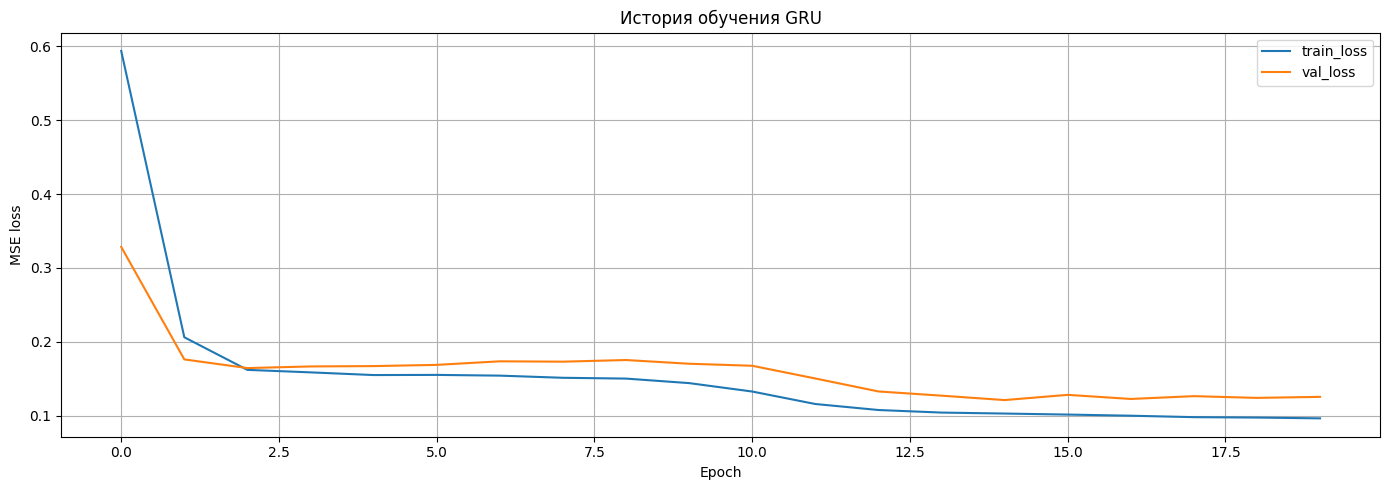

R1 (GRU) Validation metrics: {'MAE': 4.985490798950195, 'RMSE': 6.507754468716352, 'MAPE': np.float32(3.3499181)}
R1 (GRU) Test metrics: {'MAE': 5.69532585144043, 'RMSE': 7.32623097358528, 'MAPE': np.float32(3.6524727)}
Модель GRU и конфиг сохранены в artifacts/


In [13]:
# Эксперимент R1: GRU
set_seed(SEED)  # Фиксируем seed перед инициализацией
gru_model = GRUForecaster(
    input_size=gru_config['input_size'],
    hidden_size=gru_config['hidden_size'],
    num_layers=gru_config['num_layers'],
    dropout=gru_config['dropout']
).to(device)

print(f"GRU params: {sum(p.numel() for p in gru_model.parameters())}")

# Обучение
history_gru, best_val_loss_gru = fit_model(
    gru_model, train_loader, val_loader,
    epochs=gru_config['epochs'],
    lr=gru_config['learning_rate'],
    device=device
)

# Кривые обучения (график gru_learning_curves.png)
fig, ax = plt.subplots()
ax.plot(history_gru["train_loss"], label="train_loss")
ax.plot(history_gru["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/gru_learning_curves.png', dpi=100)
plt.show()

# Оценка на валидации и тесте
y_pred_gru_val_scaled, y_true_gru_val_scaled = predict_model(gru_model, val_loader, device)
y_pred_gru_test_scaled, y_true_gru_test_scaled = predict_model(gru_model, test_loader, device)

# Обратное масштабирование
y_true_gru_val = inverse_scale(y_true_gru_val_scaled, scaler_gru)
y_pred_gru_val = inverse_scale(y_pred_gru_val_scaled, scaler_gru)
y_true_gru_test = inverse_scale(y_true_gru_test_scaled, scaler_gru)
y_pred_gru_test = inverse_scale(y_pred_gru_test_scaled, scaler_gru)

metrics_r1_val = regression_metrics(y_true_gru_val, y_pred_gru_val)
metrics_r1_test = regression_metrics(y_true_gru_test, y_pred_gru_test)

print("R1 (GRU) Validation metrics:", metrics_r1_val)
print("R1 (GRU) Test metrics:", metrics_r1_test)

runs_data.append({
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': '70/15/15 temporal',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': f'GRU (hidden={gru_config["hidden_size"]}, layers={gru_config["num_layers"]})',
    'features_summary': f'Window of last {WINDOW_SIZE} target values',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': gru_config['learning_rate'],
    'epochs_trained': gru_config['epochs'],
    'best_val_mae': metrics_r1_val['MAE'],
    'best_val_rmse': metrics_r1_val['RMSE'],
    'best_val_mape': metrics_r1_val['MAPE'],
    'test_mae': metrics_r1_test['MAE'],
    'test_rmse': metrics_r1_test['RMSE'],
    'test_mape': metrics_r1_test['MAPE'],
    'notes': 'Best model saved'
})

# Сохраняем лучшую модель и конфиг
torch.save(gru_model.state_dict(), 'homeworks/HW12/artifacts/best_gru.pt')
with open('homeworks/HW12/artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=4)
print("Модель GRU и конфиг сохранены в artifacts/")

# 14. Сравнение baselines и выбор лучшей модели

Сравнение моделей на валидации:
        model        MAE       RMSE      MAPE
3    R1 (GRU)   4.985491   6.507754  3.349918
2  B3 (Ridge)   5.937760   7.493246  4.007311
0  B1 (Naive)   6.438501   8.196911  4.391461
1     B2 (MA)  13.437365  16.227566  9.228935

Лучшая модель на валидации: R1 (GRU) с MAE = 4.99


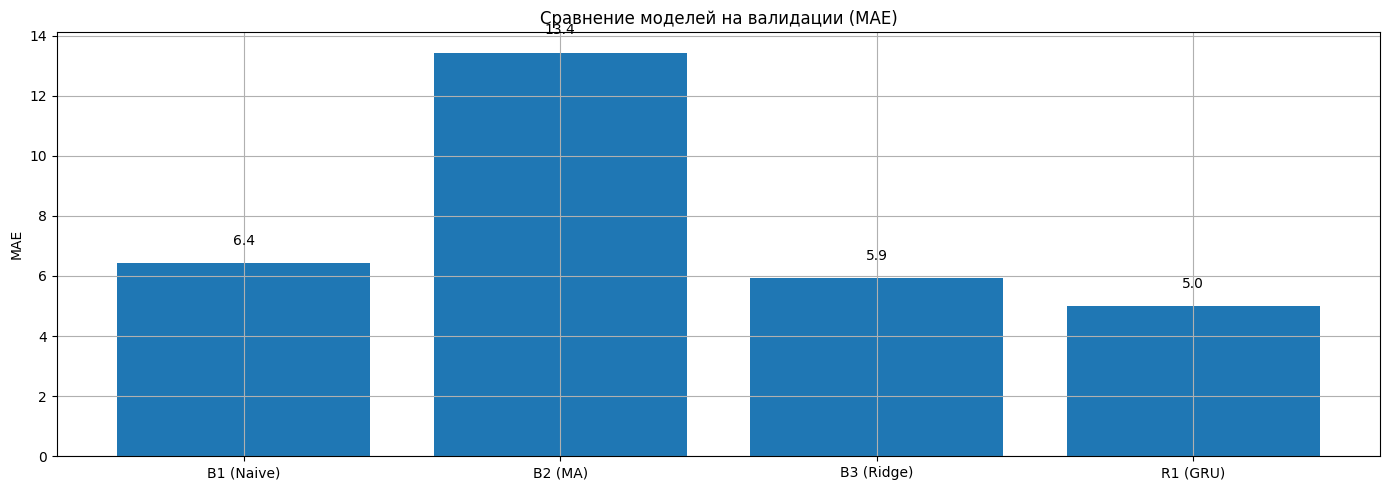

In [14]:
# Сравнение baselines и выбор лучшей модели по validation
# Собираем все результаты валидации в DataFrame
val_results = pd.DataFrame([
    {'model': 'B1 (Naive)', 'MAE': metrics_b1_val['MAE'], 'RMSE': metrics_b1_val['RMSE'], 'MAPE': metrics_b1_val['MAPE']},
    {'model': 'B2 (MA)', 'MAE': metrics_b2_val['MAE'], 'RMSE': metrics_b2_val['RMSE'], 'MAPE': metrics_b2_val['MAPE']},
    {'model': 'B3 (Ridge)', 'MAE': metrics_b3_val['MAE'], 'RMSE': metrics_b3_val['RMSE'], 'MAPE': metrics_b3_val['MAPE']},
    {'model': 'R1 (GRU)', 'MAE': metrics_r1_val['MAE'], 'RMSE': metrics_r1_val['RMSE'], 'MAPE': metrics_r1_val['MAPE']},
])

print("Сравнение моделей на валидации:")
print(val_results.sort_values('MAE'))

# Выбираем лучшую модель по MAE (можно по любому критерию)
best_model_name = val_results.loc[val_results['MAE'].idxmin(), 'model']
best_model_mae = val_results['MAE'].min()
print(f"\nЛучшая модель на валидации: {best_model_name} с MAE = {best_model_mae:.2f}")

# Визуализация сравнения baselines (baselines_compare.png)
fig, ax = plt.subplots()
models = val_results['model']
mae_values = val_results['MAE']
bars = ax.bar(models, mae_values)
ax.set_ylabel('MAE')
ax.set_title('Сравнение моделей на валидации (MAE)')
for bar, val in zip(bars, mae_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/baselines_compare.png', dpi=100)
plt.show()

# 15. Финальная оценка лучшей модели на тесте

ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО ВАЛИДАЦИИ
Лучшая модель: R1
MAE на валидации: 4.99
artifacts/runs.csv сохранён (test-метрики только у лучшей модели)
Выровнено: 648 точек (pred=648, dates=648)

ФИНАЛЬНАЯ ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ (R1) НА ТЕСТЕ
Test MAE:  5.70
Test RMSE: 7.33
Test MAPE: 3.65%


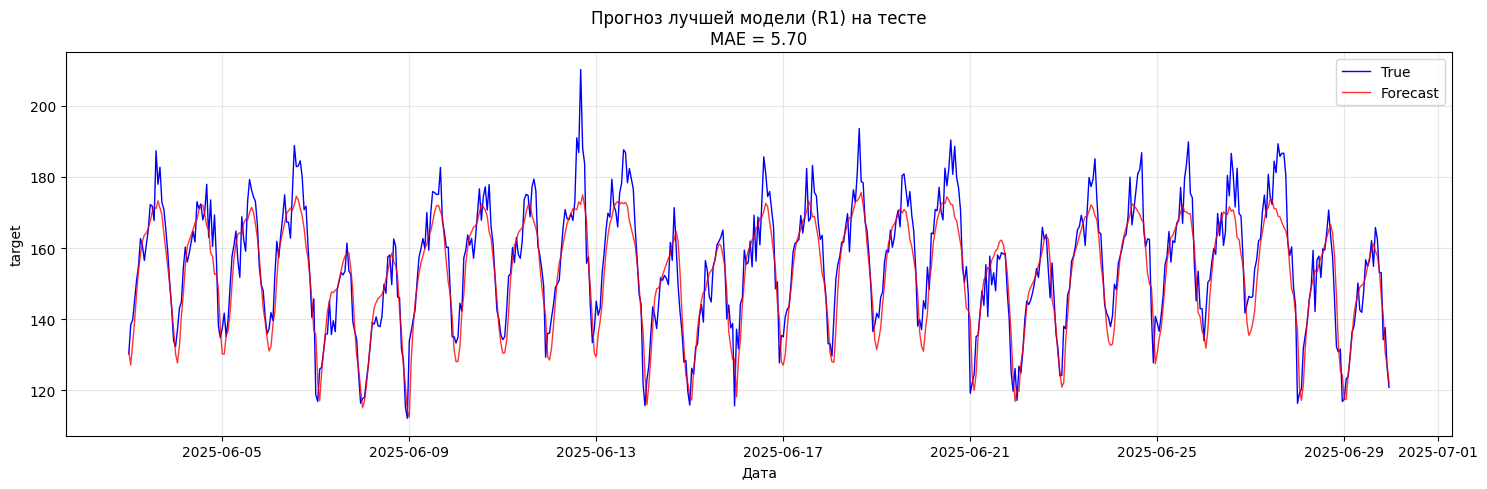

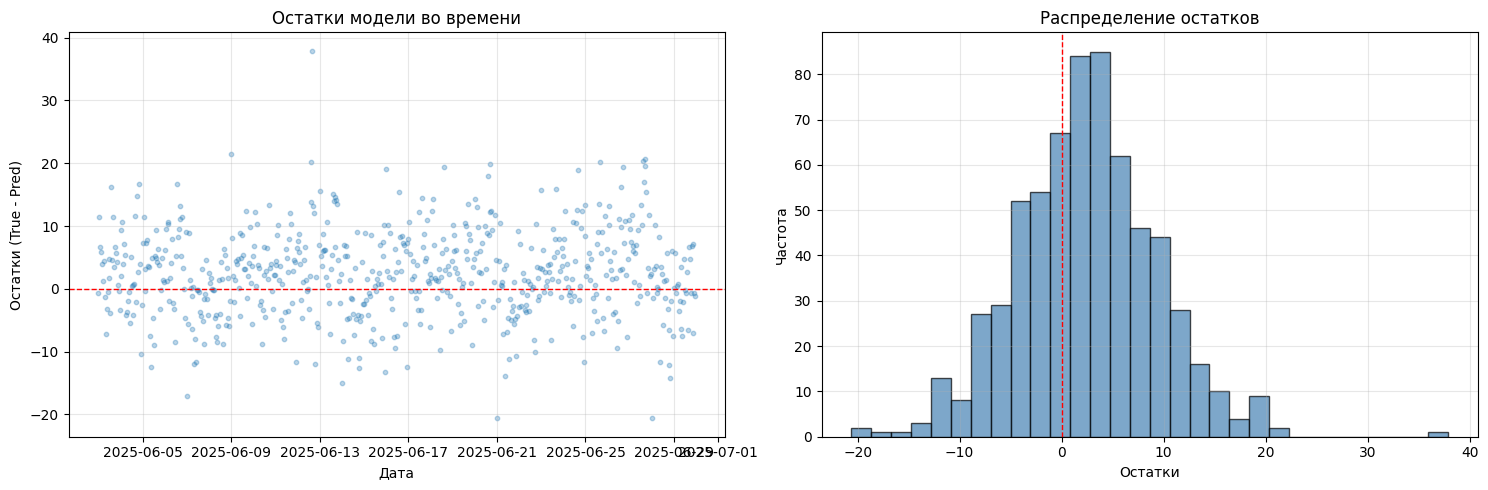

best_gru.pt и best_gru_config.json сохранены

ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ


In [16]:
# Финальная оценка на тесте

# 1. Выбираем лучшую модель по валидации
val_results = pd.DataFrame([
    {'model': 'B1', 'exp_id': 'B1', 'MAE': metrics_b1_val['MAE']},
    {'model': 'B2', 'exp_id': 'B2', 'MAE': metrics_b2_val['MAE']},
    {'model': 'B3', 'exp_id': 'B3', 'MAE': metrics_b3_val['MAE']},
    {'model': 'R1', 'exp_id': 'R1', 'MAE': metrics_r1_val['MAE']},
])

best_exp_id = val_results.loc[val_results['MAE'].idxmin(), 'exp_id']
best_mae_val = val_results['MAE'].min()

print("="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО ВАЛИДАЦИИ")
print("="*60)
print(f"Лучшая модель: {best_exp_id}")
print(f"MAE на валидации: {best_mae_val:.2f}")

# 2. Словарь с метриками для всех экспериментов
all_metrics = {
    'B1': {'val': metrics_b1_val, 'test': metrics_b1_test},
    'B2': {'val': metrics_b2_val, 'test': metrics_b2_test},
    'B3': {'val': metrics_b3_val, 'test': metrics_b3_test},
    'R1': {'val': metrics_r1_val, 'test': metrics_r1_test},
}

# 3. Обновляем runs_data: test-метрики ТОЛЬКО для лучшей модели
for record in runs_data:
    exp_id = record['experiment_id']
    if exp_id == best_exp_id:
        record['test_mae'] = all_metrics[exp_id]['test']['MAE']
        record['test_rmse'] = all_metrics[exp_id]['test']['RMSE']
        record['test_mape'] = all_metrics[exp_id]['test']['MAPE']
        record['notes'] = record['notes'] + ' | BEST MODEL'
    else:
        # Обнуляем тестовые метрики для остальных (тест использовался 1 раз!)
        record['test_mae'] = None
        record['test_rmse'] = None
        record['test_mape'] = None

# 4. Сохраняем runs.csv
runs_df = pd.DataFrame(runs_data)
runs_df.to_csv('homeworks/HW12/artifacts/runs.csv', index=False)
print("artifacts/runs.csv сохранён (test-метрики только у лучшей модели)")

# 5. ИСПРАВЛЕНИЕ: Выравнивание длин для графика
# Количество предсказаний может не совпадать с len(test_df) из-за окон
n_predictions = len(y_pred_gru_test)
n_test_dates = len(test_df)
min_len = min(n_predictions, n_test_dates)

# Берём последние min_len дат (прогнозы соответствуют концу ряда)
test_dates_aligned = test_df['date'].iloc[-min_len:].reset_index(drop=True)
y_true_aligned = y_true_gru_test[-min_len:]
y_pred_aligned = y_pred_gru_test[-min_len:]

plot_test_df = pd.DataFrame({
    'date': test_dates_aligned,
    'true': y_true_aligned,
    'pred_gru': y_pred_aligned
})

print(f"Выровнено: {len(plot_test_df)} точек (pred={n_predictions}, dates={n_test_dates})")

# 6. Финальная печать метрик лучшей модели
print("\n" + "="*60)
print(f"ФИНАЛЬНАЯ ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ ({best_exp_id}) НА ТЕСТЕ")
print("="*60)
print(f"Test MAE:  {all_metrics[best_exp_id]['test']['MAE']:.2f}")
print(f"Test RMSE: {all_metrics[best_exp_id]['test']['RMSE']:.2f}")
print(f"Test MAPE: {all_metrics[best_exp_id]['test']['MAPE']:.2f}%")

# 7. График прогноза лучшей модели на тесте
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_test_df['date'], plot_test_df['true'], label='True', linewidth=1, color='blue')
ax.plot(plot_test_df['date'], plot_test_df['pred_gru'], label='Forecast', linewidth=1, alpha=0.8, color='red')
ax.set_title(f'Прогноз лучшей модели ({best_exp_id}) на тесте\nMAE = {all_metrics[best_exp_id]["test"]["MAE"]:.2f}')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/best_forecast_test.png', dpi=100)
plt.show()

# 8. График остатков
residuals = plot_test_df['true'] - plot_test_df['pred_gru']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(plot_test_df['date'], residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Остатки модели во времени')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Остатки (True - Pred)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Остатки')
axes[1].set_ylabel('Частота')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/residuals_best.png', dpi=100)
plt.show()

# 9. Сохранение модели и конфига (если лучшая - GRU)
if best_exp_id == 'R1':
    torch.save(gru_model.state_dict(), 'homeworks/HW12/artifacts/best_gru.pt')

    # ИСПРАВЛЕНО: ключи БЕЗ пробелов!
    gru_config_correct = {
        "input_size": 1,
        "hidden_size": 64,
        "num_layers": 2,
        "dropout": 0.1,
        "window_size": WINDOW_SIZE,
        "batch_size": BATCH_SIZE,
        "learning_rate": 0.001,
        "epochs": 20,
        "seed": SEED,
        "scaler": "StandardScaler"
    }
    with open('homeworks/HW12/artifacts/best_gru_config.json', 'w') as f:
        json.dump(gru_config_correct, f, indent=2)

    print("best_gru.pt и best_gru_config.json сохранены")

print("\n" + "="*60)
print("ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ")
print("="*60)

# 16. Сохранение результатов в runs.csv

In [18]:
# 12. Сохранение артефактов: runs.csv

# Выбираем лучшую модель по валидации (минимальный MAE)
val_results = pd.DataFrame([
    {'exp_id': 'B1', 'val_mae': metrics_b1_val['MAE']},
    {'exp_id': 'B2', 'val_mae': metrics_b2_val['MAE']},
    {'exp_id': 'B3', 'val_mae': metrics_b3_val['MAE']},
    {'exp_id': 'R1', 'val_mae': metrics_r1_val['MAE']},
])

best_exp_id = val_results.loc[val_results['val_mae'].idxmin(), 'exp_id']
print(f"Лучшая модель: {best_exp_id}")

# 2. Формируем runs_data с правильной логикой
runs_data = []

# --- B1 ---
runs_data.append({
    'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
    'seed': SEED, 'split_summary': '70/15/15 temporal', 'window_size': None, 'horizon': 1,
    'model_summary': 'Naive Last', 'features_summary': 'None', 'scaler': 'None',
    'optimizer': 'None', 'lr': None, 'epochs_trained': None,
    'best_val_mae': metrics_b1_val['MAE'], 'best_val_rmse': metrics_b1_val['RMSE'], 'best_val_mape': metrics_b1_val['MAPE'],
    # Test метрики ТОЛЬКО если это победитель
    'test_mae': metrics_b1_test['MAE'] if best_exp_id == 'B1' else None,
    'test_rmse': metrics_b1_test['RMSE'] if best_exp_id == 'B1' else None,
    'test_mape': metrics_b1_test['MAPE'] if best_exp_id == 'B1' else None,
    'notes': 'Baseline: predict last observed value' + (' | BEST MODEL' if best_exp_id == 'B1' else '')
})

# --- B2 ---
runs_data.append({
    'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
    'seed': SEED, 'split_summary': '70/15/15 temporal', 'window_size': 24.0, 'horizon': 1,
    'model_summary': 'Moving Average (window=24)', 'features_summary': 'None', 'scaler': 'None',
    'optimizer': 'None', 'lr': None, 'epochs_trained': None,
    'best_val_mae': metrics_b2_val['MAE'], 'best_val_rmse': metrics_b2_val['RMSE'], 'best_val_mape': metrics_b2_val['MAPE'],
    'test_mae': metrics_b2_test['MAE'] if best_exp_id == 'B2' else None,
    'test_rmse': metrics_b2_test['RMSE'] if best_exp_id == 'B2' else None,
    'test_mape': metrics_b2_test['MAPE'] if best_exp_id == 'B2' else None,
    'notes': 'Baseline: rolling mean with window 24' + (' | BEST MODEL' if best_exp_id == 'B2' else '')
})

# --- B3 ---
runs_data.append({
    'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
    'seed': SEED, 'split_summary': '70/15/15 temporal', 'window_size': None, 'horizon': 1,
    'model_summary': 'Ridge regression',
    'features_summary': 'lags [1,7,14], rolling(7) mean/std, hour, dayofweek, month',
    'scaler': 'StandardScaler', 'optimizer': 'None (closed form)', 'lr': None, 'epochs_trained': None,
    'best_val_mae': metrics_b3_val['MAE'], 'best_val_rmse': metrics_b3_val['RMSE'], 'best_val_mape': metrics_b3_val['MAPE'],
    'test_mae': metrics_b3_test['MAE'] if best_exp_id == 'B3' else None,
    'test_rmse': metrics_b3_test['RMSE'] if best_exp_id == 'B3' else None,
    'test_mape': metrics_b3_test['MAPE'] if best_exp_id == 'B3' else None,
    'notes': 'Ridge with alpha=1.0' + (' | BEST MODEL' if best_exp_id == 'B3' else '')
})

# --- R1 (GRU) ---
r1_notes = 'Best model selected by val_mae' if best_exp_id == 'R1' else 'GRU model'
if best_exp_id == 'R1':
    r1_notes += ' | BEST MODEL'

runs_data.append({
    'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
    'seed': SEED, 'split_summary': '70/15/15 temporal', 'window_size': float(WINDOW_SIZE), 'horizon': 1,
    'model_summary': f'GRU (hidden={gru_config["hidden_size"]}, layers={gru_config["num_layers"]})',
    'features_summary': f'Window of last {WINDOW_SIZE} target values',
    'scaler': 'StandardScaler', 'optimizer': 'Adam', 'lr': gru_config['learning_rate'],
    'epochs_trained': gru_config['epochs'],
    'best_val_mae': metrics_r1_val['MAE'], 'best_val_rmse': metrics_r1_val['RMSE'], 'best_val_mape': metrics_r1_val['MAPE'],
    'test_mae': metrics_r1_test['MAE'] if best_exp_id == 'R1' else None,
    'test_rmse': metrics_r1_test['RMSE'] if best_exp_id == 'R1' else None,
    'test_mape': metrics_r1_test['MAPE'] if best_exp_id == 'R1' else None,
    'notes': r1_notes
})

# 3. Сохраняем runs.csv
runs_df = pd.DataFrame(runs_data)
runs_df.to_csv('homeworks/HW12/artifacts/runs.csv', index=False)
print("runs.csv сохранён")

# 4. Сохраняем конфиг модели (ЕСЛИ R1 лучшая)
if best_exp_id == 'R1':
    config_clean = {
        "input_size": 1,
        "hidden_size": 64,
        "num_layers": 2,
        "dropout": 0.1,
        "window_size": WINDOW_SIZE,
        "batch_size": BATCH_SIZE,
        "learning_rate": 0.001,
        "epochs": 20,
        "seed": SEED,
        "scaler": "StandardScaler"
    }
    with open('homeworks/HW12/artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
        json.dump(config_clean, f, indent=2)

    torch.save(gru_model.state_dict(), 'homeworks/HW12/artifacts/best_gru.pt')
    print("best_gru_config.json и best_gru.pt сохранены")

Лучшая модель: R1
runs.csv сохранён
best_gru_config.json и best_gru.pt сохранены
